In [12]:
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    RobertaModel,
    DataCollatorWithPadding,
    set_seed
)
from transformers.modeling_outputs import SequenceClassifierOutput

from datasets import Dataset
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import json
import os
from datetime import datetime

print("="*70)
print("MENTAL HEALTH TEXT CLASSIFICATION TRAINING")
print("="*70)

# Reproducibility
SEED = 42
set_seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

# ============= CONFIG =============
CONFIG = {
    "model_name": "roberta-base",
    "max_length": 512,
    "num_labels": 7,
    "batch_size": 8,
    "num_epochs": 5,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "gradient_accumulation_steps": 2,
    "eval_steps": 250,
    "logging_steps": 50,
    "save_total_limit": 2,
    "early_stopping_patience": 4,
    "label_smoothing": 0.05,
    "output_dir": "./models/mental_health_roberta_hybrid_final",
}

# Choose implementation
IMPLEMENTATION_TYPE = "hybrid" 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Implementation: {IMPLEMENTATION_TYPE}")

# Load label mapping + class weights
with open("models/mental_health_roberta/label_mapping.json", "r") as f:
    label_mapping = json.load(f)

with open("models/mental_health_roberta/class_weights.json", "r") as f:
    class_weights_dict = json.load(f)

id2label = {int(v): k for k, v in label_mapping.items()}
label2id = {k: int(v) for k, v in label_mapping.items()}

class_weights = [0.0] * CONFIG["num_labels"]
for k, v in class_weights_dict.items():
    class_weights[int(k)] = float(v)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)



MENTAL HEALTH TEXT CLASSIFICATION TRAINING
Device: cuda
Implementation: hybrid


In [13]:

# ============= LOAD DATA =============
print("\n[2/6] Loading datasets...")

train_df = pd.read_csv("data/train.csv")
val_df   = pd.read_csv("data/val.csv")
test_df  = pd.read_csv("data/test.csv")

print(f"+ Train: {len(train_df)} samples")
print(f"+ Val:   {len(val_df)} samples")
print(f"+ Test:  {len(test_df)} samples")

train_dataset = Dataset.from_pandas(train_df)
val_dataset   = Dataset.from_pandas(val_df)
test_dataset  = Dataset.from_pandas(test_df)

print("\n+ Training set class distribution:")
for class_name, class_idx in sorted(label_mapping.items(), key=lambda x: x[1]):
    count = (train_df["label"] == class_idx).sum()
    print(f"  [{class_idx}] {class_name}: {count}")



[2/6] Loading datasets...
+ Train: 35058 samples
+ Val:   7512 samples
+ Test:  7513 samples

+ Training set class distribution:
  [0] Normal: 10716
  [1] Anxiety: 2515
  [2] Depression: 10462
  [3] Stress: 1602
  [4] Suicidal: 7397
  [5] Bipolar: 1744
  [6] Personality disorder: 622


In [14]:

# ============= TOKENIZATION =============
print("\n[3/6] Loading tokenizer and tokenizing...")

tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"], use_fast=True)

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=CONFIG["max_length"]
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset   = val_dataset.map(tokenize_function, batched=True)
test_dataset  = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
val_dataset   = val_dataset.remove_columns(["text"])
test_dataset  = test_dataset.remove_columns(["text"])

train_dataset = train_dataset.rename_column("label", "labels")
val_dataset   = val_dataset.rename_column("label", "labels")
test_dataset  = test_dataset.rename_column("label", "labels")

train_dataset.set_format("torch")
val_dataset.set_format("torch")
test_dataset.set_format("torch")

# Dynamic padding (faster than padding=max_length always)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Tokenization complete.")



[3/6] Loading tokenizer and tokenizing...


Map:   0%|          | 0/35058 [00:00<?, ? examples/s]

Map:   0%|          | 0/7512 [00:00<?, ? examples/s]

Map:   0%|          | 0/7513 [00:00<?, ? examples/s]

Tokenization complete.


In [15]:

# ============= MODEL DEFINITIONS =============

class RobertaBiLSTMCNNClassifier(nn.Module):
    def __init__(
        self,
        model_name: str,
        num_labels: int,
        lstm_hidden: int = 256,
        lstm_layers: int = 1,
        bidirectional: bool = True,
        num_filters: int = 128,
        kernel_sizes=(2, 3, 4),
        dropout: float = 0.35
    ):
        super().__init__()

        self.num_labels = num_labels
        self.roberta = RobertaModel.from_pretrained(model_name)

        hidden_size = self.roberta.config.hidden_size
        lstm_out_dim = lstm_hidden * (2 if bidirectional else 1)

        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=bidirectional
        )

        self.lstm_norm = nn.LayerNorm(lstm_out_dim)

        self.convs = nn.ModuleList([
            nn.Conv1d(hidden_size, num_filters, k) for k in kernel_sizes
        ])

        cnn_out_dim = num_filters * len(kernel_sizes)
        final_dim = hidden_size + lstm_out_dim + cnn_out_dim

        self.fc_norm = nn.LayerNorm(final_dim)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(final_dim, num_labels)

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        roberta_outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )

        sequence_output = roberta_outputs.last_hidden_state  # (B,T,H)
        cls_embedding = sequence_output[:, 0, :]             # (B,H)

        # BiLSTM
        lstm_out, _ = self.lstm(sequence_output)
        lstm_out = self.lstm_norm(lstm_out)

        mask = attention_mask.unsqueeze(-1).float()
        lstm_pooled = (lstm_out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

        # CNN
        x_cnn = sequence_output.transpose(1, 2)  # (B,H,T)
        cnn_feats = []
        for conv in self.convs:
            conv_out = torch.relu(conv(x_cnn))
            pooled = torch.max(conv_out, dim=2).values
            cnn_feats.append(pooled)

        cnn_pooled = torch.cat(cnn_feats, dim=1)

        combined = torch.cat([cls_embedding, lstm_pooled, cnn_pooled], dim=1)
        combined = self.fc_norm(combined)
        combined = self.dropout(combined)

        logits = self.classifier(combined)
        return SequenceClassifierOutput(logits=logits)


print("\n[4/6] Loading model...")

model = RobertaBiLSTMCNNClassifier(
    model_name=CONFIG["model_name"],
    num_labels=CONFIG["num_labels"],
    lstm_hidden=256,
    lstm_layers=1,
    bidirectional=True,
    num_filters=128,
    kernel_sizes=(2, 3, 4),
    dropout=0.35
)

# attach config so trainer.save_model creates config.json
model.config = model.roberta.config
model.config.num_labels = CONFIG["num_labels"]
model.config.id2label = {str(k): v for k, v in id2label.items()}
model.config.label2id = label2id
model.config.model_type_custom = "hybrid"

model.to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"+ Model loaded: {num_params / 1e6:.2f}M parameters")



[4/6] Loading model...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


+ Model loaded: 127.65M parameters


In [16]:

# ============= TRAINING SETUP =============
print("\n[5/6] Setting up training...")

os.makedirs(CONFIG["output_dir"], exist_ok=True)
os.makedirs("results", exist_ok=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1_macro": f1,
        "precision_macro": precision,
        "recall_macro": recall
    }

class WeightedTrainer(Trainer):
    def __init__(self, class_weights_tensor, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_fct = nn.CrossEntropyLoss(
            weight=class_weights_tensor,
            label_smoothing=CONFIG["label_smoothing"]
        )

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = self.loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir=CONFIG["output_dir"],
    num_train_epochs=CONFIG["num_epochs"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["batch_size"] * 2,
    gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],

    learning_rate=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
    warmup_ratio=CONFIG["warmup_ratio"],

    lr_scheduler_type="cosine",
    fp16=torch.cuda.is_available(),

    eval_strategy="steps",
    eval_steps=CONFIG["eval_steps"],

    save_strategy="steps",
    save_steps=CONFIG["eval_steps"],

    logging_steps=CONFIG["logging_steps"],

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    save_total_limit=CONFIG["save_total_limit"],
    max_grad_norm=1.0,

    report_to="none"
)

trainer = WeightedTrainer(
    class_weights_tensor=class_weights_tensor,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=CONFIG["early_stopping_patience"])]
)

print("+ Trainer initialized")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



[5/6] Setting up training...
+ Trainer initialized


In [17]:

# ============= TRAINING =============
print("\n[6/6] Starting training...")
print("="*70)
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

train_result = trainer.train()

print("\n" + "="*70)
print("+ TRAINING COMPLETE")
print("="*70)

# Evaluate on test
print("\nEvaluating on test set...")
test_metrics = trainer.evaluate(test_dataset)
print(test_metrics)

# Save final model
trainer.save_model(CONFIG["output_dir"])
tokenizer.save_pretrained(CONFIG["output_dir"])

# Ensure implementation type stored in config.json
if hasattr(model, "config") and model.config is not None:
    model.config.model_type_custom = IMPLEMENTATION_TYPE
    model.config.max_length_used = CONFIG["max_length"]
    model.config.save_pretrained(CONFIG["output_dir"])

print(f"\nModel saved to: {CONFIG['output_dir']}")



[6/6] Starting training...
Start time: 2026-02-18 08:48:02


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
250,1.865465,1.658180,0.598642,0.440810,0.448195,0.481381
500,1.240424,1.285725,0.682641,0.609456,0.637422,0.670063
750,1.205030,1.084736,0.769036,0.717049,0.691902,0.779200
1000,1.231593,1.106659,0.767173,0.725573,0.738597,0.761559
1250,1.113106,1.060228,0.777955,0.738447,0.734374,0.777151
1500,1.119997,0.995106,0.777290,0.751591,0.739127,0.809689
1750,1.090496,0.994275,0.811901,0.784165,0.767250,0.809743
2000,1.033113,0.979255,0.818823,0.797380,0.785334,0.818042
2250,1.014282,0.977394,0.812700,0.787972,0.767036,0.815995
2500,0.981112,0.926116,0.831470,0.811984,0.795141,0.839629



+ TRAINING COMPLETE

Evaluating on test set...


{'eval_loss': 0.9591352939605713, 'eval_accuracy': 0.8382803141221882, 'eval_f1_macro': 0.8167203548499876, 'eval_precision_macro': 0.8214399741014937, 'eval_recall_macro': 0.818975559729374, 'eval_runtime': 88.9051, 'eval_samples_per_second': 84.506, 'eval_steps_per_second': 5.287, 'epoch': 3.079397672826831}

Model saved to: ./models/mental_health_roberta_hybrid_final


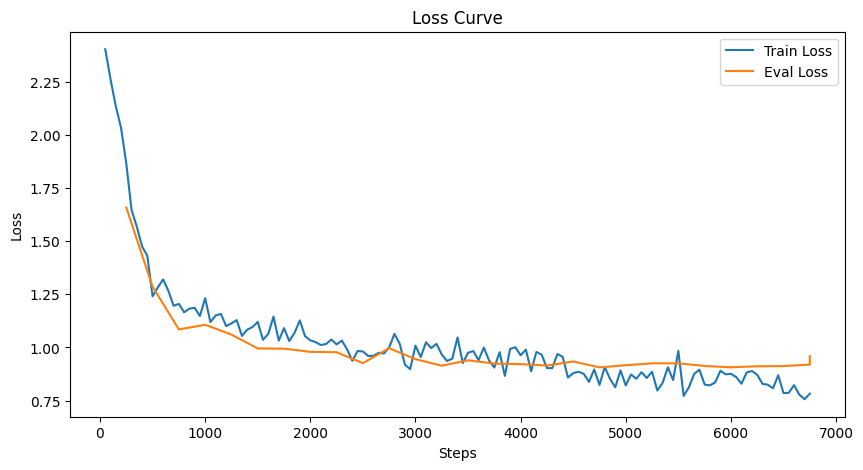

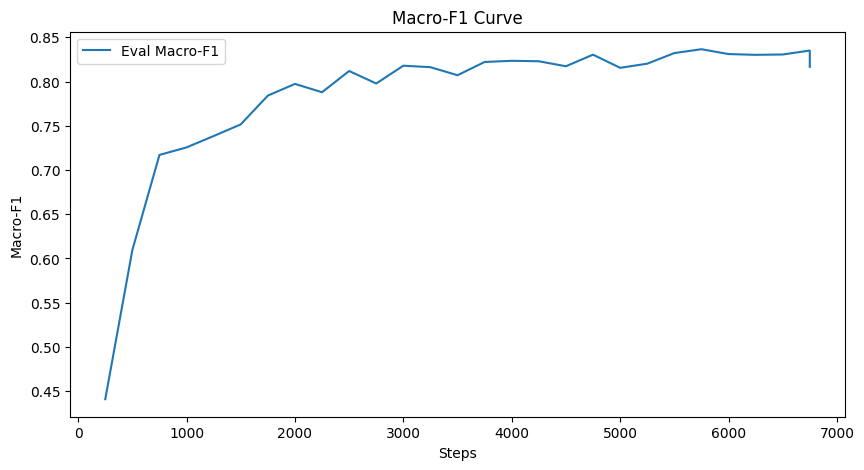

In [18]:

# ============= TRAINING CURVES =============
log_history = trainer.state.log_history

train_loss = [x["loss"] for x in log_history if "loss" in x]
train_steps = [x["step"] for x in log_history if "loss" in x]

eval_loss = [x["eval_loss"] for x in log_history if "eval_loss" in x]
eval_acc = [x["eval_accuracy"] for x in log_history if "eval_accuracy" in x]
eval_f1_macro = [x["eval_f1_macro"] for x in log_history if "eval_f1_macro" in x]
eval_steps = [x["step"] for x in log_history if "eval_loss" in x]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, label="Train Loss")
plt.plot(eval_steps, eval_loss, label="Eval Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(eval_steps, eval_f1_macro, label="Eval Macro-F1")
plt.xlabel("Steps")
plt.ylabel("Macro-F1")
plt.title("Macro-F1 Curve")
plt.legend()
plt.show()
